**Retail Sales and Retail Use Business Registrations**

In [ ]:
# The dataset used in this project was obtained from the official U.S. Government Open Data Portal (Data.gov). 
# The Retail Sales and Retail Use Business Registrations dataset originates from the State of Iowa. 
# It contains information about businesses registered for retail sales and use tax purposes. 

# The dataset includes details such as:
        - Business status
        - Business location
        - Tax type
        - Permit issue dates
        - Permit cancellation dates

# This information is valuable for analyzing 
        - Business registration patterns 
        - Geographic distribution 
        - Tax classifications 
        - Trends in business activity across the state 

# The dataset provides a reliable source for conducting exploratory data analysis (EDA) and generating insights that can support business and economic decision-making.

<!-- # The dataset used in this project was obtained from the official U.S Government open data portal.The Retail Sales and Retail use Business Registrations.
# Dataset originates from the State of Iowa and contains information about business registered for retail sales and use tax purposes.It includes business status,location,
# tax type,permit issue dates,and permit cancellation dates.This information is valuable for analyzing business registration patterns,geogaphic 
# distribution,tax classifications,and trends in business activity across the state.The dataset provides a reliable source for conducting exploratory data analysis (EDA) and generating insights that can support business and economic decision-making. -->

**1) Data Loading and Initial Overview**

In [ ]:
# Import the Data Set using Pandas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\hp\Downloads\retail_sales_and_retail_use_business_registrations.csv")
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_17944\1185444898.py:1: DtypeWarning: Columns (0,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\hp\Downloads\retail_sales_and_retail_use_business_registrations.csv")


,retail_permit_number,consolidated_number,name_of_business,active_or_inactive_business,tax_type,department_business_code,business_code_description,county_fips_code,registration_county_number,business_location_county,county_name,department_city_code,address_of_the_business,city_location_of_business,state_of_business,business_zip_code,date_permit_was_issued,date_permit_was_cancelled
0,947000263,947000263,UNITED BANK OF IOWA,Inactive,Consumer Use,522110.0,Commercial Banking,19093.0,47.0,47,Ida,2.0,501 2ND ST,IDA GROVE,IA,51445-1304,1932-01-01,2022-06-30
1,147000408,NaN,ARTHUR CITY OF,Active,Retail Sales,221210.0,Natural Gas Distribution,19093.0,47.0,47,Ida,4.0,217 S MAIN ST,ARTHUR,IA,51431-8053,1934-01-01,NaN
2,116000636,NaN,BENNETT CITY OF,Active,Retail Sales,2213.0,"Water, Sewage and Other Systems",19031.0,16.0,16,Cedar,8.0,201 MAIN ST,BENNETT,IA,52721-7710,1934-01-01,NaN
3,195000671,NaN,"BUFFALO CENTER,CITY OF",Active,Retail Sales,2213.0,"Water, Sewage and Other Systems",19189.0,95.0,95,Winnebago,2.0,201 2ND AVE SW,BUFFALO CENTER,IA,50424-0000,1934-01-01,NaN
4,112000643,NaN,CITY OF ALLISON,Active,Retail Sales,9211.0,"Executive, Legislative, and Other General Gove...",19023.0,12.0,12,Butler,5.0,410 N MAIN,ALLISON,IA,50602-0000,1934-01-01,NaN


**Dataset Overview**

**The dataset contains information about retail business registrations, including:**

- Retail Permit number
- Consolidated number
- Name of Business
- Business Status (Active/Inactive)
- Tax Type
- Business Code
- County Information:Geographic identifier
- City Information
- Permit Issue Date
- Permit Cancellation Date

**Dataset Characteristics**

- Number of Records: Rows=365478,Columns=18
- Multiple categorical attributes
- Date-related information
- Business registration details

**Descriptive Analysis**

In [3]:
df.shape

(365478, 18)

In [4]:
df.dtypes

retail_permit_number            object
consolidated_number             object
name_of_business                object
active_or_inactive_business     object
tax_type                        object
department_business_code       float64
business_code_description       object
county_fips_code               float64
registration_county_number     float64
business_location_county         int64
county_name                     object
department_city_code           float64
address_of_the_business         object
city_location_of_business       object
state_of_business               object
business_zip_code               object
date_permit_was_issued          object
date_permit_was_cancelled       object
dtype: object

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365478 entries, 0 to 365477
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   retail_permit_number         365478 non-null  object 
 1   consolidated_number          208296 non-null  object 
 2   name_of_business             365478 non-null  object 
 3   active_or_inactive_business  365478 non-null  object 
 4   tax_type                     365478 non-null  object 
 5   department_business_code     296631 non-null  float64
 6   business_code_description    296631 non-null  object 
 7   county_fips_code             267754 non-null  float64
 8   registration_county_number   365360 non-null  float64
 9   business_location_county     365478 non-null  int64  
 10  county_name                  249091 non-null  object 
 11  department_city_code         249091 non-null  float64
 12  address_of_the_business      365468 non-null  object 
 13 

**2) Data Pre-processing**

● Perform all necessary cleaning steps such as:
- Handling Missing Values
- Check duplicate records
- Remove duplicate records
- Fill missing values (NaN) with the previous non-missing value in the column
- Data type conversion

**Handling Missing Values**

In [4]:
df.isnull().sum()

retail_permit_number                0
consolidated_number            157182
name_of_business                    0
active_or_inactive_business         0
tax_type                            0
department_business_code        68847
business_code_description       68847
county_fips_code                97724
registration_county_number        118
business_location_county            0
county_name                    116387
department_city_code           116387
address_of_the_business            10
city_location_of_business          50
state_of_business                1054
business_zip_code                 770
date_permit_was_issued              0
date_permit_was_cancelled      239933
dtype: int64

**Missing values in numerical columns**

In [5]:
num_cols=df.select_dtypes(include=['float64','int64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_1632\1336701965.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


**Missing values in categorical columns**

In [6]:
cat_cols=df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_1632\3886738920.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365478 entries, 0 to 365477
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   retail_permit_number         365478 non-null  object 
 1   consolidated_number          365478 non-null  object 
 2   name_of_business             365478 non-null  object 
 3   active_or_inactive_business  365478 non-null  object 
 4   tax_type                     365478 non-null  object 
 5   department_business_code     365478 non-null  float64
 6   business_code_description    365478 non-null  object 
 7   county_fips_code             365478 non-null  float64
 8   registration_county_number   365478 non-null  float64
 9   business_location_county     365478 non-null  int64  
 10  county_name                  365478 non-null  object 
 11  department_city_code         365478 non-null  float64
 12  address_of_the_business      365478 non-null  object 
 13 

In [8]:
df.isnull().sum()

retail_permit_number           0
consolidated_number            0
name_of_business               0
active_or_inactive_business    0
tax_type                       0
department_business_code       0
business_code_description      0
county_fips_code               0
registration_county_number     0
business_location_county       0
county_name                    0
department_city_code           0
address_of_the_business        0
city_location_of_business      0
state_of_business              0
business_zip_code              0
date_permit_was_issued         0
date_permit_was_cancelled      0
dtype: int64

**Check duplicate records**

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Remove duplicate records**


In [12]:
df = df.drop_duplicates()
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

Number of duplicate rows after cleaning: 0


In [13]:
df.columns

Index(['retail_permit_number', 'consolidated_number', 'name_of_business',
       'active_or_inactive_business', 'tax_type', 'department_business_code',
       'business_code_description', 'county_fips_code',
       'registration_county_number', 'business_location_county', 'county_name',
       'department_city_code', 'address_of_the_business',
       'city_location_of_business', 'state_of_business', 'business_zip_code',
       'date_permit_was_issued', 'date_permit_was_cancelled'],
      dtype='object')

**Fill missing values (NaN) with the previous non-missing value in the column**

In [10]:
df['date_permit_was_cancelled'] = df['date_permit_was_cancelled'].ffill()
df['consolidated_number'] = df['consolidated_number'].ffill()

In [11]:
df['business_zip_code']=df['business_zip_code'].ffill()

**Data type conversion**

In [12]:
df['retail_permit_number'] = pd.to_numeric(
    df['retail_permit_number'],
    errors='coerce'
).astype('Int64')

df['consolidated_number'] = pd.to_numeric(
    df['consolidated_number'],
    errors='coerce'
).astype('Int64')

df['business_zip_code'] = pd.to_numeric(
    df['business_zip_code'],
    errors='coerce'
).astype('Int64')

**Object Datatype change to Numeric**

**convert date column**

In [13]:
df['date_permit_was_issued'] = pd.to_datetime(
    df['date_permit_was_issued'],
    errors='coerce'
)

df['date_permit_was_cancelled'] = pd.to_datetime(
    df['date_permit_was_cancelled'],
    errors='coerce'
)

In [14]:
df.dtypes

retail_permit_number                    Int64
consolidated_number                     Int64
name_of_business                       object
active_or_inactive_business            object
tax_type                               object
department_business_code              float64
business_code_description              object
county_fips_code                      float64
registration_county_number            float64
business_location_county                int64
county_name                            object
department_city_code                  float64
address_of_the_business                object
city_location_of_business              object
state_of_business                      object
business_zip_code                       Int64
date_permit_was_issued         datetime64[ns]
date_permit_was_cancelled      datetime64[ns]
dtype: object

**3) Exploratory Data Analysis (EDA)**

**Descriptive statistics for the numerical columns**

In [15]:
df.describe()

,retail_permit_number,consolidated_number,department_business_code,county_fips_code,registration_county_number,business_location_county,department_city_code,business_zip_code,date_permit_was_issued,date_permit_was_cancelled
count,346121.0,334965.0,365478.000000,365478.000000,365478.000000,365478.000000,365478.000000,1545.0,365478,365478
mean,266473464.174494,165570808.879328,332195.128757,19112.522592,38.835509,41.252861,2.363590,50847.122977,2014-08-26 19:30:34.544349952,2021-12-14 02:18:55.324150784
min,2.0,2.0,238.000000,19001.000000,0.000000,0.000000,1.000000,0.0,1900-10-01 00:00:00,1959-01-02 00:00:00
25%,155005395.0,7787.0,7225.000000,19095.000000,0.000000,0.000000,1.000000,33131.0,2009-09-21 00:00:00,2021-11-11 00:00:00
50%,200158438.0,8096.0,423390.000000,19115.000000,33.000000,42.000000,1.000000,51063.0,2019-02-01 00:00:00,2021-11-11 00:00:00
75%,306004513.0,304403626.0,459120.000000,19153.000000,77.000000,77.000000,2.000000,75001.0,2023-01-02 00:00:00,2021-11-11 00:00:00
max,999000426.0,999000426.0,928120.000000,19197.000000,99.000000,99.000000,21.000000,99223.0,2027-04-01 00:00:00,2027-02-28 00:00:00
std,196414456.06477,220128726.329428,254166.462343,47.451363,34.527198,34.401550,2.966247,26412.114857,NaN,NaN


**Cleaned Dataset saved to csv file**

In [16]:
df.to_csv("cleaned_dataset_retail_business_data.csv", index=False)

**4) Visualizations**

**1) Business status distibution - count plot**

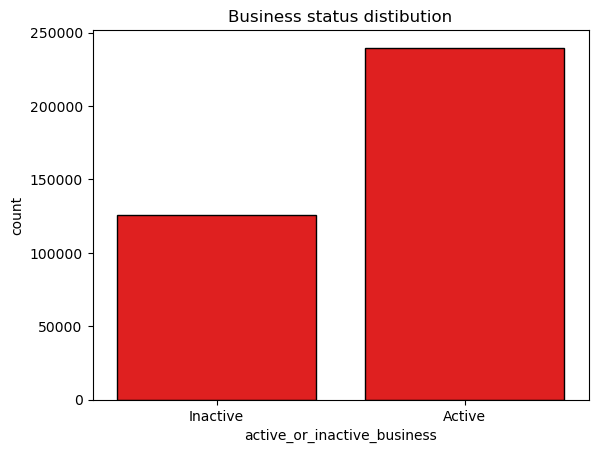

In [10]:
sns.countplot(data=df,x='active_or_inactive_business',color='red',edgecolor='black')
plt.title('Business status distibution')
plt.show()

 **No.of active_or_inactive_business**

In [5]:
df['active_or_inactive_business'].value_counts()

active_or_inactive_business
Active      239739
Inactive    125739
Name: count, dtype: int64

**Insights**

- Active Business shows highest amount of count.It indicates healthy business environment.
  
- Inactive Business shows that many registered business are no longer operating.This may indicate higher usiness closure rates,

- economic challenges,strong competition, or market saturation, which can affect the overall health of the retail sector.


**2) Number of Businesses by County using groupby - Bar Plot**

In [6]:
county_business = df.groupby('county_name').size()

In [13]:
print(county_business.head(10))

county_name
Polk             37755
Linn             16341
Scott            11361
Johnson           9462
Story             9063
Black Hawk        9020
Dubuque           7447
Woodbury          7093
Dallas            6544
Pottawattamie     5400
dtype: int64


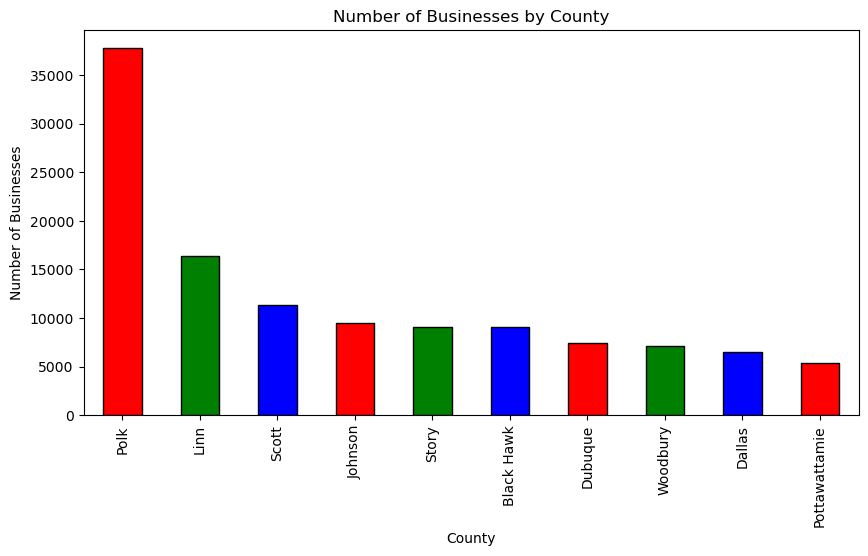

In [15]:
county_business = df.groupby('county_name').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
county_business.plot(kind='bar',color=['red','green','blue'],edgecolor='black')

plt.title('Number of Businesses by County')
plt.xlabel('County')
plt.ylabel('Number of Businesses')
plt.show()

**Insights**

- Number of Businesses by County shows the geographical distribution of retail businesses.
  
- Counties with the highest Count represent the major business hub and economic centers.

- Counties with lower counts may indicate smaller populations and lower business activity.

**3) Top 5 Cities by Registrations usig groupby - Bar Plot**

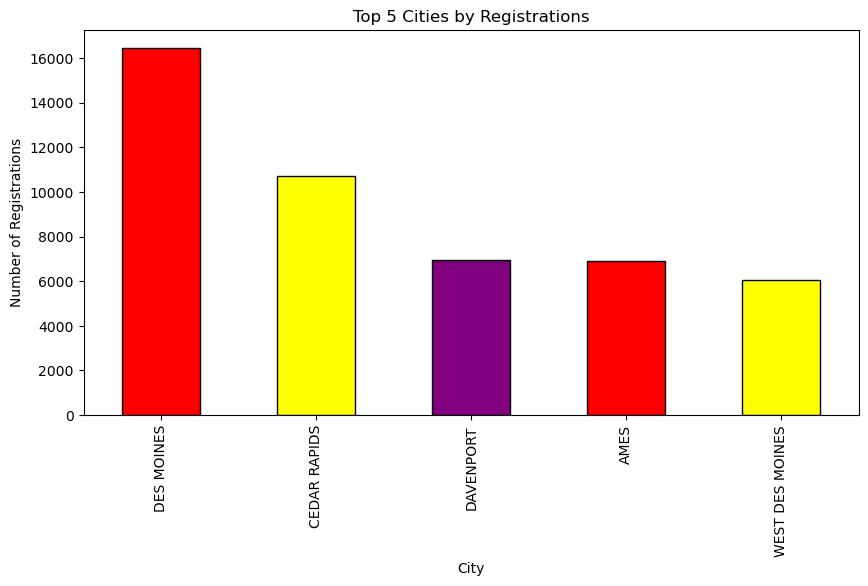

In [17]:
top_cities=df.groupby('city_location_of_business').size().sort_values(ascending=False).head(5)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar',color=['red','yellow','purple'],edgecolor='black')

plt.title('Top 5 Cities by Registrations')
plt.xlabel('City')
plt.ylabel('Number of Registrations')
plt.show()

**Insights**

- Top 5 Cities by Registrations identifies that the cities with the highest concentration of registered business.

- Higher registration counts indicate stronger economic development,larger populations and more favourable business environment.
    

**4) Tax Type Distribution by groupby- Pie Chart**

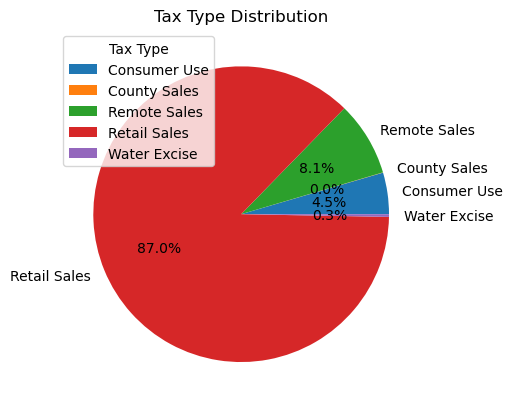

In [34]:
tax_distribution = df.groupby('tax_type').size()

plt.pie(
    tax_distribution,
    labels=tax_distribution.index,
    autopct='%1.1f%%',
    
)

plt.title('Tax Type Distribution')
plt.legend(title='Tax Type')
plt.show()

**Insights**

- The Tax Type Distribution analysis reveals the proportion of businesses registered under each tax category.
  
- Retail Sales contributes the highest proportion of registrations.

- This indicates that retail sales businesses form the largest segment of the business population in the dataset.

**5) Business Registrations by Year - Line Chart**

In [17]:
df["Year"]=df["date_permit_was_issued"].dt.year


In [22]:
yearly_registrations= df.groupby('Year').size()

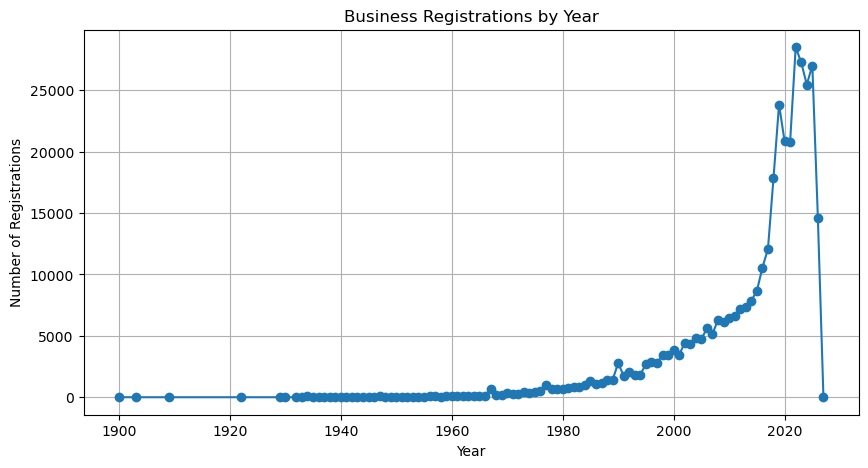

In [25]:
plt.figure(figsize=(10,5))
plt.plot(yearly_registrations.index,
         yearly_registrations.values,
         marker='o'
         )

plt.title("Business Registrations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Registrations")
plt.grid()

**Insights**

- An upward trend indicates an increase in Business registrations.
  
- A downward trend indicates fewer new Business registrations.

**6) Retail Permit Number vs Consolidated Number - Scatter Plot**

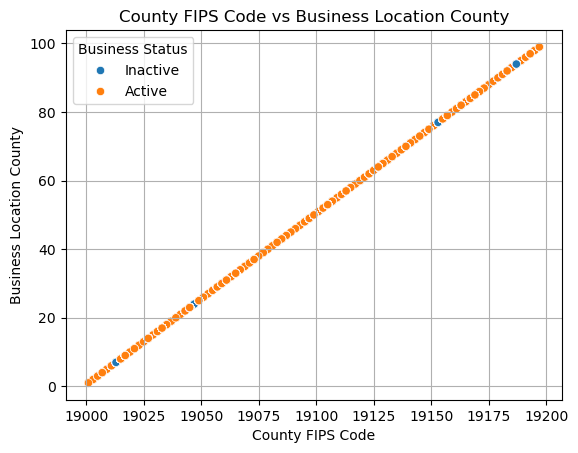

In [6]:
sns.scatterplot(
    data=df,
    x='county_fips_code',
    y='business_location_county',
    hue='active_or_inactive_business'
)
plt.title('County FIPS Code vs Business Location County')
plt.xlabel('County FIPS Code')
plt.ylabel('Business Location County')
plt.legend(title='Business Status')
plt.grid()
plt.show()

**Insights**

- Active businesses are more densly distributed across most counties.
  
- Inactive businesses appear less frequently.


**7) Business ZIP Code Distribution -Histogram**

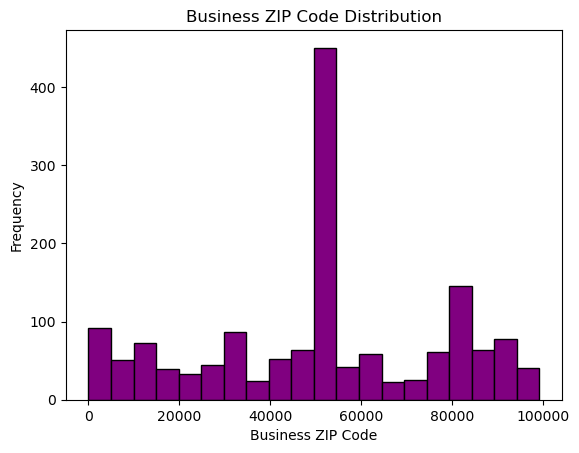

In [19]:

plt.hist(
    df['business_zip_code'],
    bins=20,
    color='purple',
    edgecolor='black'
)

plt.title('Business ZIP Code Distribution')
plt.xlabel('Business ZIP Code')
plt.ylabel('Frequency')
plt.show()

**Insights**

- High peak → High concentration of retail businesses shows higher economic activity and customer demand.
  
- Medium peak → Moderate number of businesses.

- Low peak → Few businesses are registered in that ZIP code range.

**8) Business ZIP Code by Business Status - Box Plot**

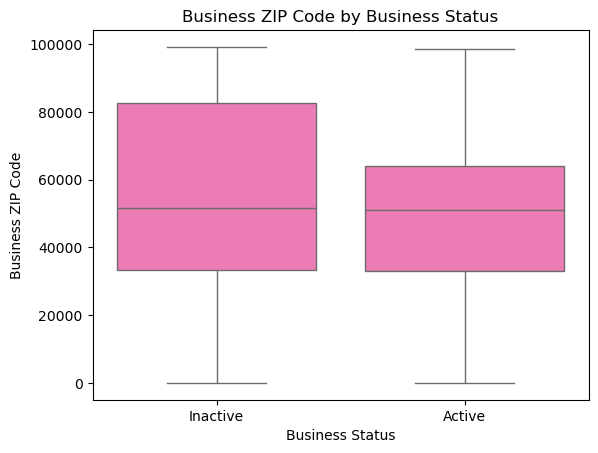

In [37]:
sns.boxplot(
    data=df,
    x='active_or_inactive_business',
    y='business_zip_code',
    color='hotpink'
)

plt.title('Business ZIP Code by Business Status')
plt.xlabel('Business Status')
plt.ylabel('Business ZIP Code')

plt.show()

**Insights**

- The box plot compares the distribution of Business ZIP Codes for Active and Inactive businesses.
  
- The line inside the box represents the median Business ZIP Code.

- The whiskers show the spread of ZIP Code values excluding outliers.

- Points outside the whiskers are outliers, representing unusual ZIP Code values.

**9) Business Location County vs Business ZIP code - Heatmap**

In [16]:
corr = df[['business_location_county','business_zip_code']].corr()

corr

,business_location_county,business_zip_code
business_location_county,1.000000,-0.090593
business_zip_code,-0.090593,1.000000


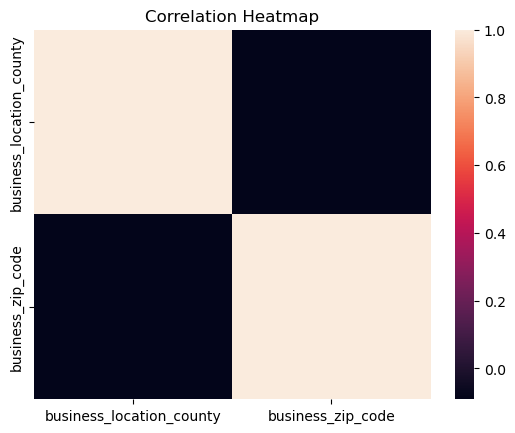

In [17]:
sns.heatmap(corr)
plt.title('Correlation Heatmap')

plt.show()

**Insights**

- Businesses are distributed across different counties and ZIP codes.

- Darker-colored cells indicate a stronger relationship or higher concentration of businesses.

- Lighter-colored cells indicate a weaker relationship or fewer businesses.

- The heatmap helps identify business concentration across different geographic locations.

- Values close to 1.0 indicate a strong positive relationship.

- Values around 0.5–0.8 indicate a moderate relationship.

- Values close to 0.0 indicate a weak or no relationship.

**10) Distribution of Business Permit Issue Years -KDE(Kernel Density Estimation Plot)**

- Extract the year from date_permit_was_issued
  
- Create the KDE Plot

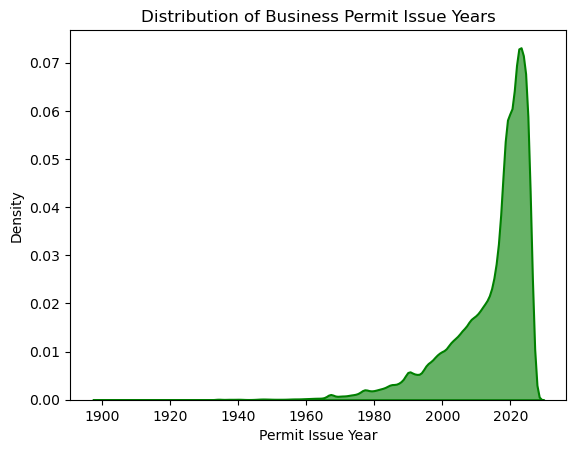

In [25]:

df["permit_year"]=df["date_permit_was_issued"].dt.year


sns.kdeplot(
    data=df,
    x='permit_year',
    fill=True,
    alpha=0.6,
    linewidth=1.5,color='green'
)

plt.title("Distribution of Business Permit Issue Years")
plt.xlabel("Permit Issue Year")
plt.ylabel("Density")

plt.show()
         

**Insights**

- The KDE plot shows the distribution of business permit issue years.
  
- Peaks indicate years in which more permits were issued.

- Lower density indicates fewer permits issued during those years.

- "fill" parameter to fill the area under the curve

- "alpha" and "linewidth" parameters to make the plot more visually appealing


**11) Business ZIP Code Distribution by Business Status - Violin Plot**

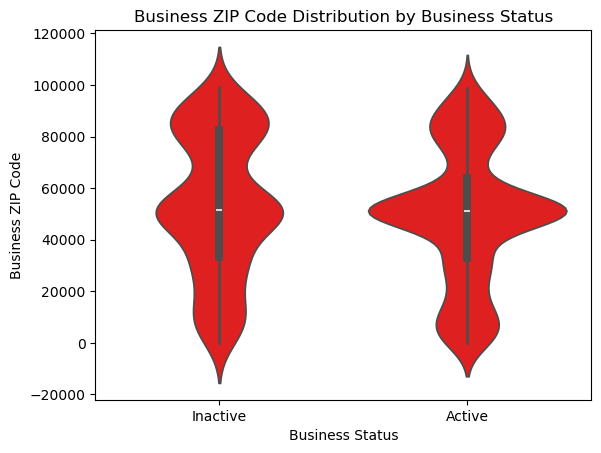

In [19]:

sns.violinplot(
    data=df,
    x='active_or_inactive_business',
    y='business_zip_code',
    color='red'
)

plt.title("Business ZIP Code Distribution by Business Status")
plt.xlabel("Business Status")
plt.ylabel("Business ZIP Code")

plt.show()

**Insights**

- A violin plot is a type of data visualization that combines aspects of both box plots and density plots.
  
- Wider sections of the violin indicate ZIP code ranges where more businesses are concentrated.

- Narrow sections indicate ZIP code ranges with fewer businesses.

- The black bar inside (like a mini boxplot).

- White dot = median.

- Thick black bar = interquartile range (IQR).

- Thin black line = rest of the distribution (like whiskers in a boxplot).

**12) Department Business Code vs Business ZIP Code -Joint Plot**

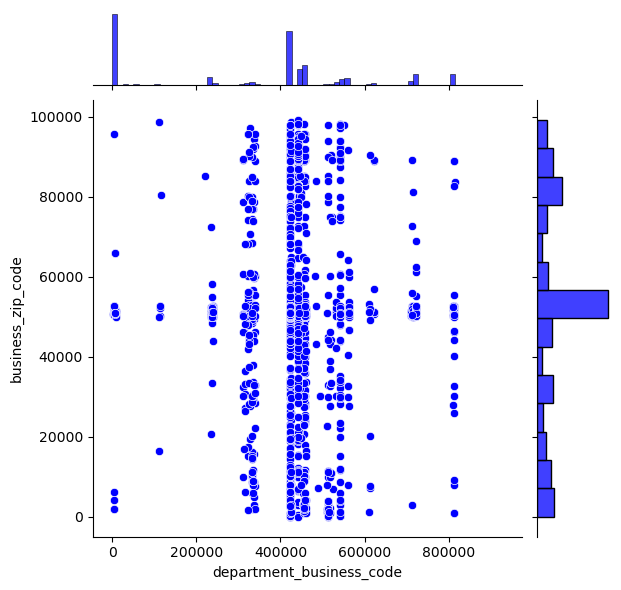

In [22]:
sns.jointplot(
    data=df,
    x='department_business_code',
    y='business_zip_code',
    color='blue'
)

plt.show()

**Insights**

- Joint plot is a powerful visualization technique in seaborn that combines two different plots in one visualization.
  
- The scatter plot in the center shows how businesses are distributed across different department codes and ZIP codes.

- The top histogram shows the distribution of Department Business Codes.

- The right histogram shows the distribution of Business ZIP Codes.

- Areas where many points are clustered indicate higher concentrations of businesses for certain department code and ZIP code combinations.

- Widely scattered points indicate little or no clear relationship between the two variables.


**5) Insight Generation and Report** 

**1. Data Analysis Summary**

**The Retail Sales and Retail Use Business Registrations dataset was analyzed to understand business registration trends, business status, 
geographical****distribution, and relationships among different business attributes. The dataset was cleaned by handling missing values, removing duplicates**,**converting date columns into datetime format, and correcting data types before performing exploratory data analysis (EDA).**

**Data Cleaning**

**Data Preparation**

**Before analysis, the dataset was cleaned to improve data quality.**

**Steps performed:**

- Removed duplicate records.
  
- Handled missing values in numerical and categorical columns.

- Converted the registration date column to datetime format.

- Verified and corrected data types.

- Checked for inconsistencies and invalid values.

- This ensures that the analysis is accurate and reliable.


**1) Business Status Distribution - Count Plot**

**Interpretation:**

- The count plot shows that Active businesses significantly outnumber Inactive businesses.

- This indicates that most registered retail businesses are currently operational.

- The relatively smaller number of inactive businesses suggests a stable retail business environment.


**Key Insights**
  
- Active businesses dominate the dataset.

- Inactive businesses represent only a small portion of total registrations.

- The distribution indicates healthy business continuity and sustained retail activity.

- The smaller proportion of inactive businesses indicates that business closures or deregistrations are relatively limited.

- This analysis helps assess the health and sustainability of the retail sector and can support business planning and policy decisions.



**2) Business Registration by Year - Line Chart**

**Interpretation**

- The line chart shows how the number of business registrations changes from year to year.

- Some years exhibit noticeable increases in registrations, indicating periods of business growth.

- Other years show lower registration counts, which may reflect economic slowdowns or changes in market conditions.


**Key Insights**

- Business registrations fluctuate over the years rather than remaining steady.

- Peak years indicate higher entrepreneurial activity and increased retail business growth.

- Years with fewer registrations may correspond to economic challenges or reduced business expansion.

- Lower registration years may reflect economic slowdowns, policy changes, or other external factors affecting new business registrations.

- The trend helps identify periods of growth and decline in retail business registations.

- An increasing trend suggests growing interest in establishing retail businesses, while a decreasing trend may indicate reduced business formation.


  
**3) Top 5 Cities by Registrations usig groupby - Bar Plot****

**Interpretation**

- The bar plot ranks cities according to their total business registrations.
  
- The city with the tallest bar has the highest number of registered retail businesses.

- The top five cities account for a significant share of the total registrations, indicating that retail activity is concentrated in major urban areas.


  **Key Insights**

- The top-ranked city has the highest number of business registrations.

- The remaining four cities also show strong retail business activity but with comparatively fewer registrations.

- Higher registration counts may be associated with larger populations, better infrastructure, and stronger economic opportunities.

- Cities with higher registration counts are likely to have larger populations, stronger economies, and better commercial infrastructure.

- The comparison highlights regional differences in retail business activity and identifies areas with the greatest business concentration.



**4) Tax Type Distribution by groupby- Pie Chart****

**Interpretation**

- The pie chart displays the percentage share of each tax type in the dataset.

- The largest slice represents the most common tax type among registered businesses.

- Smaller slices indicate tax types with fewer registered businesses.

- The distribution helps identify which tax categories are most prevalent in the retail sector.


**Key Insights**

- One or a few tax types account for the majority of business registrations.

- Some tax types have a relatively small share, indicating they are less common.

- The variation in proportions reflects the diversity of tax classifications among retail businesses.

- The distribution demonstrates that business registrations are concentrated in one or a few tax categories, rather than being evenly spread across   - all tax types.

- Understanding tax type distribution can help in tax administration and business policy planning.

**5) Retail Permit Number vs Consolidated Number - Scatter Plot**

**Interpretation**

- Active businesses are more densly distributed across most counties.
  
- Inactive businesses appear less frequently.


**Key Insights**

- The scatter plot shows no strong positive or negative correlation between Retail Permit Number and Consolidated Number.

- Data points are widely scattered, indicating that the two variables are assigned independently.

- A few isolated points may appear because of the wide range of identifier values, but they do not represent meaningful outliers.

- No clear clusters or trends are visible.

- Both columns are unique identification numbers, they do not represent measurable business characteristics such as sales, or business performance.

  
**6) Business ZIP Code Distribution - Histogram**

**Interpretation**

- The histogram shows that business registrations are not evenly distributed across ZIP codes.

- A few ZIP codes have a high concentration of businesses, forming prominent peaks in the histogram.

- Many ZIP codes have relatively fewer registered businesses, indicating lower business activity in those areas.


**Key Insights**

- Business registrations are concentrated in a limited number of ZIP codes.

- The highest peaks represent ZIP codes with the largest number of registered businesses.

- Most ZIP codes contain comparatively fewer businesses.

- The uneven distribution indicates that retail activity is centered in major commercial or urban areas.

- The histogram helps identify regions with high business density for further market or geographic analysis.


**7) Business ZIP Code by Business Status - Box Plot**

**Interpretation**

-The box plot compares the central tendency and spread of ZIP codes for Active and Inactive businesses.

- Both groups have a similar range of ZIP codes, indicating that businesses of both statuses are located across many regions.

- The median values may differ slightly, but the overall distributions overlap considerably.


**Key Insights**

- Active and Inactive businesses are distributed across similar ZIP code ranges.
  
- Active businesses generally show a wider spread, indicating they operate across more locations.

- The box plot highlights variations in business concentration across different regions.

- The whiskers show the spread of ZIP Code values excluding outliers.

- Points outside the whiskers are outliers, representing unusual ZIP Code values.


**8) Business Location County vs Business ZIP code - Heatmap**

**Interpretation**

- Darker shades indicate higher concentrations of businesses within particular county–ZIP code combinations.

- Lighter shades represent lower business concentrations.

- The heatmap makes it easy to identify geographic clusters and areas with significant retail activity.


**Key Insights**

- Business registrations are not evenly distributed across all counties and ZIP codes.

- Certain county–ZIP code combinations show higher concentrations of registered businesses.

- Darker regions in the heatmap highlight major commercial or urban areas with increased retail activity.

- Many county–ZIP code combinations have relatively fewer businesses, indicating lower commercial presence.

- The heatmap effectively identifies geographical patterns and business clusters, making it easier to compare retail activity across different regions.


**9) Distribution of Business Permit Issue Years -KDE(Kernel Density Estimation Plot)**

**Interpretation**

- Peaks in the KDE curve represent years with a high concentration of business permit issuances.

- Lower sections of the curve indicate years with fewer permits issued.

- The smooth density curve makes it easier to observe long-term trends than a histogram.

  
**Key Insights**

- The KDE plot highlights years with the highest concentration of business permit issuances, represented by the tallest peaks.

- Business permit issuance is not uniformly distributed over time, indicating fluctuations in registration activity.

- High-density regions suggest periods of increased business growth and registration.

- Low-density regions indicate years with fewer new business permits, possibly due to economic or policy-related factors.

- The smooth distribution helps identify overall trends without being affected by individual yearly fluctuations.


**10) Business ZIP Code Distribution by Business Status - Violin Plot**

**Interpretation**

- The width of the violin represents the density of businesses at different ZIP code ranges.

- Wider sections indicate higher concentrations of businesses, while narrower sections represent fewer businesses.

- Comparing the two violins helps identify differences in the geographical distribution of Active and Inactive businesses.


**Key Insights**

- Active businesses are distributed across a wider range of ZIP codes, indicating a broader geographic presence.
  
- Inactive businesses tend to be more concentrated in fewer ZIP code ranges.

- Wider portions of the violin indicate ZIP code ranges with a high density of business registrations.

- Both business statuses share some overlapping ZIP code distributions, suggesting that Active and Inactive businesses operate in many of the
- same regions.

- The plot reveals differences in the density and spread of business locations more effectively than a standard box plot.

**Significant Patterns, Correlations, and Anomalies**


**Significant Patterns**

- **Active businesses** make up the majority of registrations, indicating a stable retail business environment.

- Business registrations **fluctuate over the years**, with some years showing higher registration activity than others.

- **Retail businesses are concentrated in a few major cities and ZIP codes,** suggesting that commercial activities are centered in urban areas.

- Small number of **Department Business Codes** account for most business registrations, other business categories have relatively fewer registrations.

- The **Tax Type distribution** is uneven, with one or two tax categories representing the majority of registered businesses.

- The **KDE plot** shows that business permit issuances are concentrated during certain years, reflecting periods of increased business growth.


 **Correlations**

- The **Retail Permit Number vs Consolidated Number** scatter plot shows no meaningful correlation, as both variables are unique business identifiers.

- The **Business Location County vs Business ZIP Code heatmap** highlights geographical clusters,

- indicating that businesses are concentrated within specific county–ZIP code combinations.

- The **Business ZIP Code by Business Status box plot and violin plot** show that Active and Inactive businesses share similar geographic

- distributions, although Active businesses have a wider spread across ZIP codes.


**Anomalies**

- Several **ZIP codes** have exceptionally high numbers of registered businesses, appearing as peaks in the histogram and density plots.

- Some Department Business Codes have significantly higher registration counts than others, indicating dominant retail sectors.

- Registration activity is uneven across years, with noticeable peaks and declines rather than a consistent trend.

- The Business Registration by Year line chart shows noticeable peaks and dips, indicating that registration activity varies considerably over time - - rather than following a steady trend.

- The KDE plot also highlights years with unusually high concentrations of permit issuances, reflecting periods of increased business growth.

**Overall Summary**

**The analysis reveals that the retail business sector is largely active and stable,with most businesses currently operational. Business 
registrations are concentrated in a few cities, ZIP codes, and business categories, indicating strong commercial hubs. Registration trends vary over time,reflecting changes in economic conditions and business activity. Geographic visualizations show clear clustering of businesses.**

**Recommendations**

- Encourage business development in **underrepresented cities and ZIP codes** to promote balanced regional growth.

- Monitor **Inactive businesses** to identify common reasons for business closure and improve business support programs.

- Focus investment and policy initiatives on **emerging business categories** while continuing to support high-performing retail sectors.

- Perform additional analysis using variables such as **Business revenue, employment, or sales performance** to gain deeper business insights.

- Apply **predictive analytics or machine learning** to forecast future business registrations and identify potential growth opportunities.